In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
from cartopy.util import add_cyclic_point
import cartopy.feature as feature

In [3]:
filename='sst.mnmean.nc'
ds=xr.open_dataset(filename)
ds

<xarray.Dataset> Size: 120MB
Dimensions:    (time: 461, lat: 180, lon: 360, nbnds: 2)
Coordinates:
  * lat        (lat) float32 720B 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * lon        (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * time       (time) datetime64[ns] 4kB 1981-12-01 1982-01-01 ... 2020-04-01
Dimensions without coordinates: nbnds
Data variables:
    sst        (time, lat, lon) float32 119MB ...
    time_bnds  (time, nbnds) datetime64[ns] 7kB ...
Attributes:
    title:          NOAA Optimum Interpolation (OI) SST V2
    Conventions:    CF-1.0
    history:        Wed Apr  6 13:47:45 2005: ncks -d time,0,278 SAVEs/sst.mn...
    comments:       Data described in  Reynolds, R.W., N.A. Rayner, T.M.\nSmi...
    platform:       Model
    source:         NCEP Climate Modeling Branch
    institution:    National Centers for Environmental Prediction
    References:     https://www.psl.noaa.gov/data/gridded/data.noaa.oisst.v2....
    dataset_title:  NOAA Optimum Interpolation (OI) SST V2
    source_url:     http://www.emc.ncep.noaa.gov/research/cmb/sst_analysis/

## Calculate seasonal means

In [4]:
ds_seas=ds.groupby('time.season').mean()
ds_seas

<xarray.Dataset> Size: 1MB
Dimensions:  (season: 4, lat: 180, lon: 360)
Coordinates:
  * lat      (lat) float32 720B 89.5 88.5 87.5 86.5 ... -86.5 -87.5 -88.5 -89.5
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * season   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
Data variables:
    sst      (season, lat, lon) float32 1MB -1.79 -1.79 -1.79 ... -1.79 -1.79
Attributes:
    title:          NOAA Optimum Interpolation (OI) SST V2
    Conventions:    CF-1.0
    history:        Wed Apr  6 13:47:45 2005: ncks -d time,0,278 SAVEs/sst.mn...
    comments:       Data described in  Reynolds, R.W., N.A. Rayner, T.M.\nSmi...
    platform:       Model
    source:         NCEP Climate Modeling Branch
    institution:    National Centers for Environmental Prediction
    References:     https://www.psl.noaa.gov/data/gridded/data.noaa.oisst.v2....
    dataset_title:  NOAA Optimum Interpolation (OI) SST V2
    source_url:     http://www.emc.ncep.noaa.gov/research/cmb/sst_analysis/

### Multiple ways to make multipanel plots
pyplot.subplot works similar to Matlab's subplot function.
Specify the number of rows, columns, and the "plot number"

Text(0.5, 0.98, 'SST (˚C)')

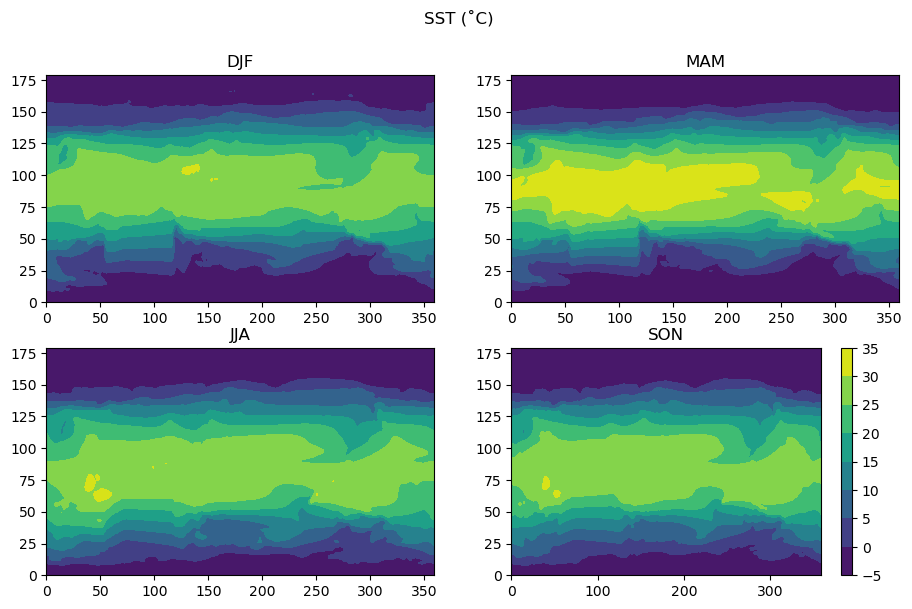

In [6]:
fig = plt.figure(figsize=(11,6.5))
plt.subplot(2,2,1)
plt.contourf(ds_seas['sst'].sel(season='DJF'))
plt.title('DJF')
plt.subplot(2,2,2)
plt.contourf(ds_seas['sst'].sel(season='MAM'))
plt.title('MAM')
plt.subplot(2,2,3)
plt.contourf(ds_seas['sst'].sel(season='JJA'))
plt.title('JJA')
plt.subplot(2,2,4)
plt.contourf(ds_seas['sst'].sel(season='SON'))
plt.title('SON')
plt.colorbar()
plt.suptitle('SST (˚C)')

This was not a very efficient way to plot the four panels, but it worked.

We could use a loop to make it more efficient. 
Also, there is the problem that the color bar has caused the last panel to be compressed.
We will deal with that later.

First, let's use a loop to plot the panels for each season, and choose colors that seem more appropriate for temperature.

Text(0.5, 0.98, 'SST (˚C)')

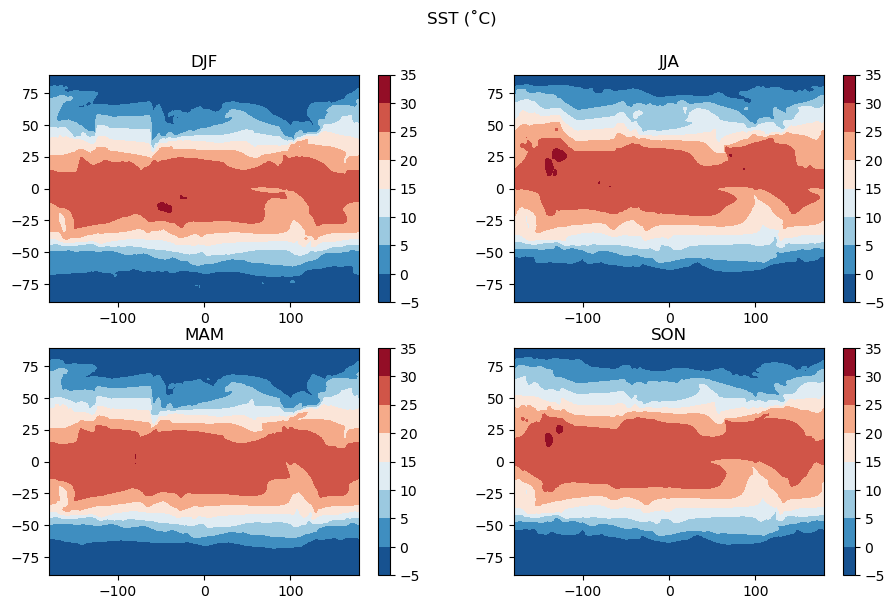

In [8]:
fig = plt.figure(figsize=(11,6.5))
clevs=np.arange(-5,36,5)
for i,seas in enumerate(ds_seas['season']):
    plt.subplot(2,2,i+1)
    plt.contourf(ds_seas.lon-180,ds_seas.lat,ds_seas['sst'].sel(season=seas),levels=clevs,cmap='RdBu_r')
    plt.title(seas.values)
    plt.colorbar()
plt.suptitle('SST (˚C)')

## What if we want to plot on a map projection?  
Its a little more complicated.
We have to use `pyplot.subplots`

.subplots creates a *figure* and populates it with *axes* objects. Like in pyplot.subplot, we specify the number of rows and columns as arguments. However, this function creates all of it in one go instead of requiring multiple calls. 

This is a utility function that makes creating axes objects more straightforward. For each "panel", the function calls the method Figure.add_subplot and sets it up in a "grid".

.subplots lets us add keywords to that add_axes call, including projections. We've been doing this in class from time to time already.

Text(0.5, 0.98, 'SST (deg C)')

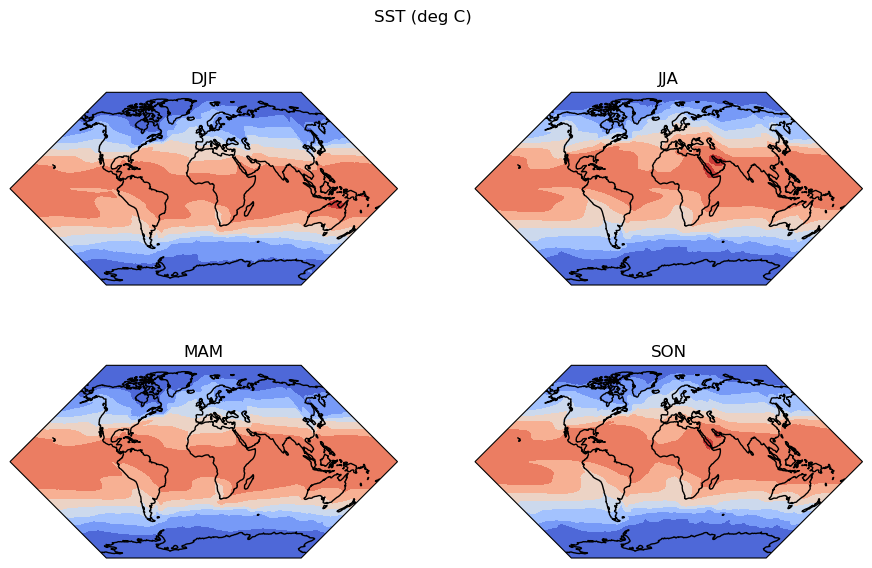

In [10]:
# Define the figure and each axis for the 2 rows and 2 columns
fig, axs = plt.subplots(nrows=2,ncols=2,
                        subplot_kw={'projection': ccrs.EckertI()},
                        figsize=(11,6.5))

# axs is a 2 dimensional array of `GeoAxes`.  
# We will flatten it into a 1-D array
axs=axs.flatten()

#Loop over all of the seasons and plot
for i,seas in enumerate(ds_seas['season']):

    # Select the season
    data=ds_seas['sst'].sel(season=seas)

    # Add the cyclic point
    data,lons=add_cyclic_point(data,coord=ds_seas['lon'])

    # Contour plot
    cs=axs[i].contourf(lons,ds_seas['lat'],data,clevs,
                      transform = ccrs.PlateCarree(),
                      cmap='cividis',extend='both')

    # Title each subplot with the name of the model
    axs[i].set_title(seas.values)

    # Draw the coastines for each subplot
    axs[i].coastlines()
plt.suptitle('SST (deg C)')

### Now lets make it look nicer 
* adding a single colorbar 
* add a big title
* label our lats and lons

Text(0.5, 0.98, 'Sea Surface Temperature from OISSTv3')

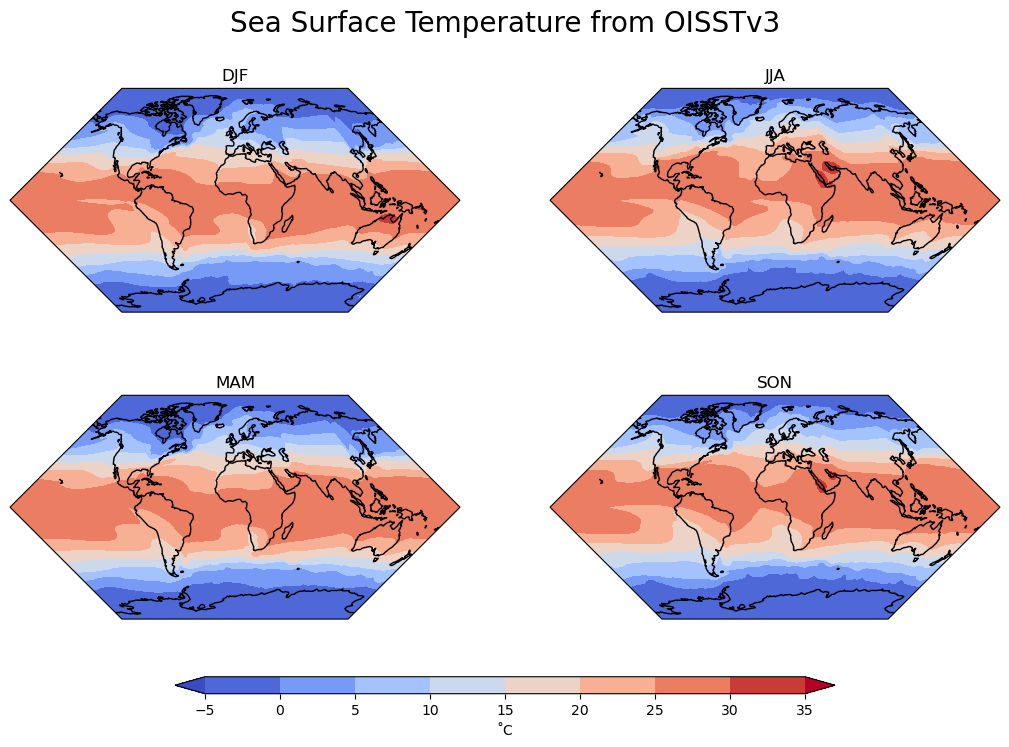

In [12]:
# Define the figure and each axis for the 2 rows and 2 columns
fig, axs = plt.subplots(nrows=2,ncols=2,
                        subplot_kw={'projection': ccrs.EckertI()},
                        figsize=(11,8.5))

# axs is a 2 dimensional array of `GeoAxes`.  
# We will flatten it into a 1-D array
axs=axs.flatten()

#Loop over all of the seasons and plot
for i,seas in enumerate(ds_seas['season']):

        # Select the season
        data=ds_seas['sst'].sel(season=seas)

        # Add the cyclic point
        data,lons=add_cyclic_point(data,coord=ds_seas['lon'])

        # Contour plot
        cs=axs[i].contourf(lons,ds_seas['lat'],data,clevs,
                          transform = ccrs.PlateCarree(),
                          cmap='cividis',extend='both')

       # Longitude labels
        # axs[i].set_xticks(np.arange(-180,181,60), crs=ccrs.PlateCarree())
        # lon_formatter = cticker.LongitudeFormatter()
        # axs[i].xaxis.set_major_formatter(lon_formatter)

        # # Latitude labels
        # axs[i].set_yticks(np.arange(-90,91,30), crs=ccrs.PlateCarree())
        # lat_formatter = cticker.LatitudeFormatter()
        # axs[i].yaxis.set_major_formatter(lat_formatter)

        # Title each subplot with the name of the season
        axs[i].set_title(seas.values)

        # Draw the coastines for each subplot
        axs[i].coastlines()
        
# Adjust the location of the subplots 
# on the page to make room for the colorbar
fig.subplots_adjust(bottom=0.25, top=0.9, left=0.05, right=0.95,
                    wspace=0.2, hspace=0.25)

# Add a colorbar axis at the bottom of the graph
cbar_ax = fig.add_axes([0.2, 0.175, 0.6, 0.02])

# Draw the colorbar
cbar=fig.colorbar(cs, cax=cbar_ax,orientation='horizontal',label='˚C')

# Add a big title at the top
plt.suptitle('Sea Surface Temperature from OISSTv3',fontsize=20)

### Faceting
Faceting allows you to plot subplots across the dimensios of an `xarray.Dataset` using many fewer lines of code. It uses the metadata to default label the subplots for you and makes a single colorbar for all subplots.
Take a look at the [documentation](https://docs.xarray.dev/en/stable/user-guide/plotting.html#plotting-faceting).

C:\Users\lortizur\AppData\Local\Temp\ipykernel_10236\4054388574.py:13: DeprecationWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for ax in fg.axes.flat:


<Figure size 1100x850 with 0 Axes>

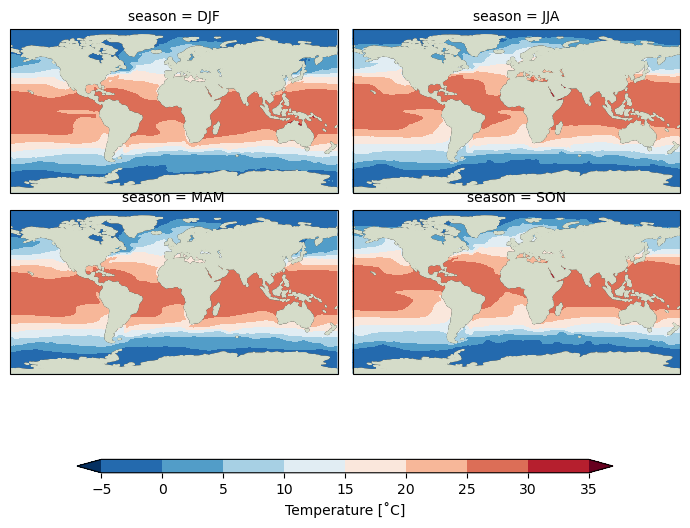

In [13]:
fig = plt.figure(figsize=(11,8.5))

fg = ds_seas['sst'].plot(x='lon',y='lat',col='season',col_wrap=2,
    levels=clevs,cmap='RdBu_r',extend='both',
    subplot_kws={"projection": ccrs.PlateCarree()},
    cbar_kwargs={
        "orientation": "horizontal",
        "shrink": 0.8,
        "aspect": 40,
        "label": "Temperature [˚C]",
    },)

for ax in fg.axes.flat:
    ax.coastlines()
    ax.add_feature(feature.LAND, zorder=2, color='#D5DCC9')


# Advanced Multipanel Plotting with Matplotlib GridSpec

Sometimes we need to create more complex visualizations. TO do that, we might have to rely on matplotlib components that offer more flexibility (at the cost of requiring us to think a bit more about the figure and axes creation process)

GridSpec provides much more flexible control over subplot layouts compared to the basic `plt.subplot()` approach. With GridSpec, you can:

- Create subplots of different sizes
- Span subplots across multiple grid cells
- Precisely control spacing between subplots
- Add colorbars in dedicated grid spaces
- Create complex, publication-ready layouts

Let's explore these capabilities using our SST data.

In [14]:
import matplotlib.gridspec as gridspec

## Basic GridSpec Usage

GridSpec allows you to define a grid and then assign subplots to specific cells or ranges of cells. Let's start with a simple example that recreates our 2x2 seasonal plot:

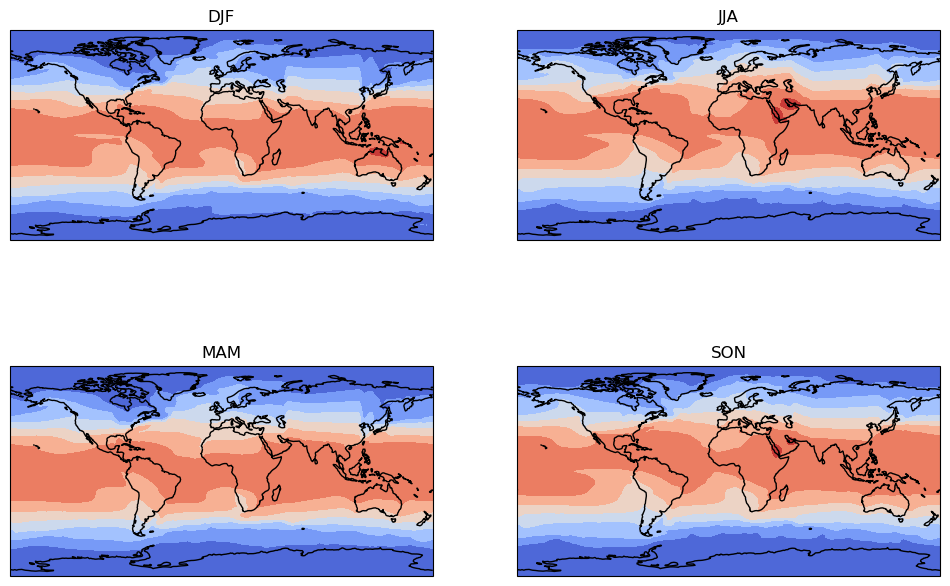

In [30]:
# Create a basic 2x2 GridSpec layout
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Create subplots using GridSpec
axs = [fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree()),
       fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree()),
       fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree()),
       fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree())]

clevs = np.arange(-5, 36, 5)

# Plot each season
for i, seas in enumerate(ds_seas['season']):
    data = ds_seas['sst'].sel(season=seas)
    data, lons = add_cyclic_point(data, coord=ds_seas['lon'])
    
    cs = axs[i].contourf(lons, ds_seas['lat'], data, clevs,
                        transform=ccrs.PlateCarree(),
                        cmap='cividis', extend='both')
    
    axs[i].set_title(f'{seas.values}', fontsize=12)
    axs[i].coastlines()
    
#     # Add lat/lon labels
#     axs[i].set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
#     axs[i].set_yticks(np.arange(-90, 91, 30), crs=ccrs.PlateCarree())
#     axs[i].xaxis.set_major_formatter(cticker.LongitudeFormatter())
#     axs[i].yaxis.set_major_formatter(cticker.LatitudeFormatter())

# plt.tight_layout()
# plt.suptitle('SST Seasonal Means - Basic GridSpec Layout', fontsize=16, y=0.98)
# plt.show()

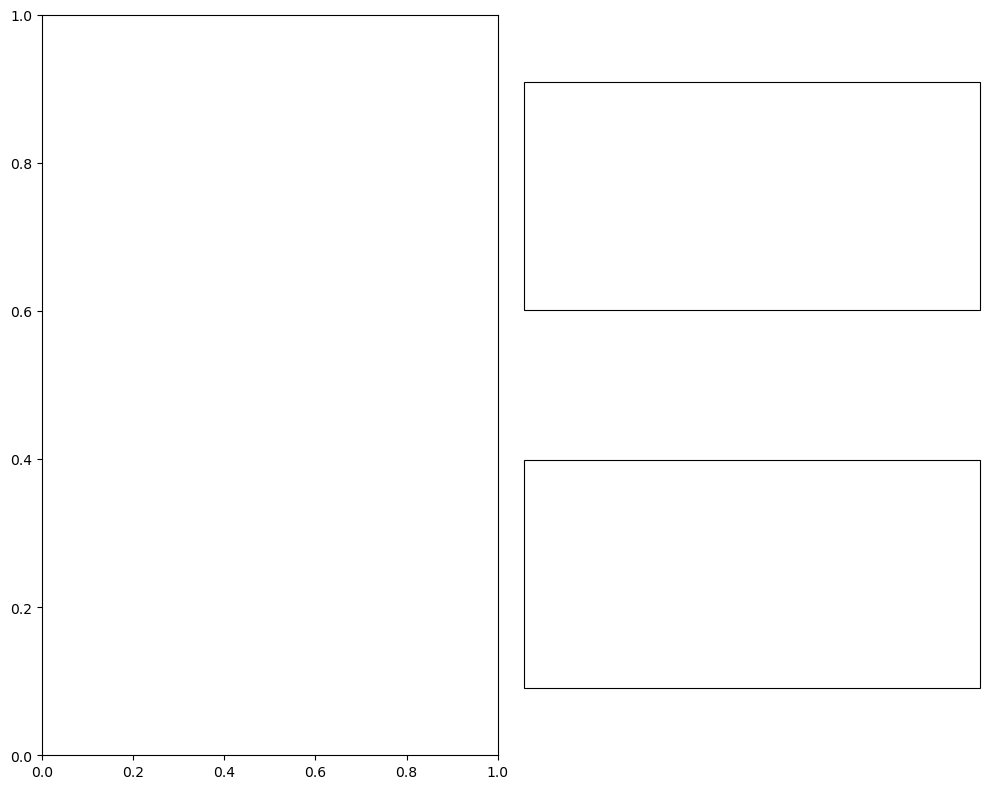

In [26]:
# Create a basic 2x2 GridSpec layout
fig = plt.figure(figsize=(10, 8), tight_layout=True)
gs = gridspec.GridSpec(2, 2, figure=fig)

# Create subplots using GridSpec
axs = [fig.add_subplot(gs[:, 0]),
       fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree()),
    #    fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree()),
       fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree())]

## Creating Subplots of Different Sizes

One of GridSpec's key advantages is creating subplots that span multiple grid cells. Let's create a layout with:
- One large main plot spanning 2 columns
- Two smaller plots below it
- A dedicated space for a colorbar

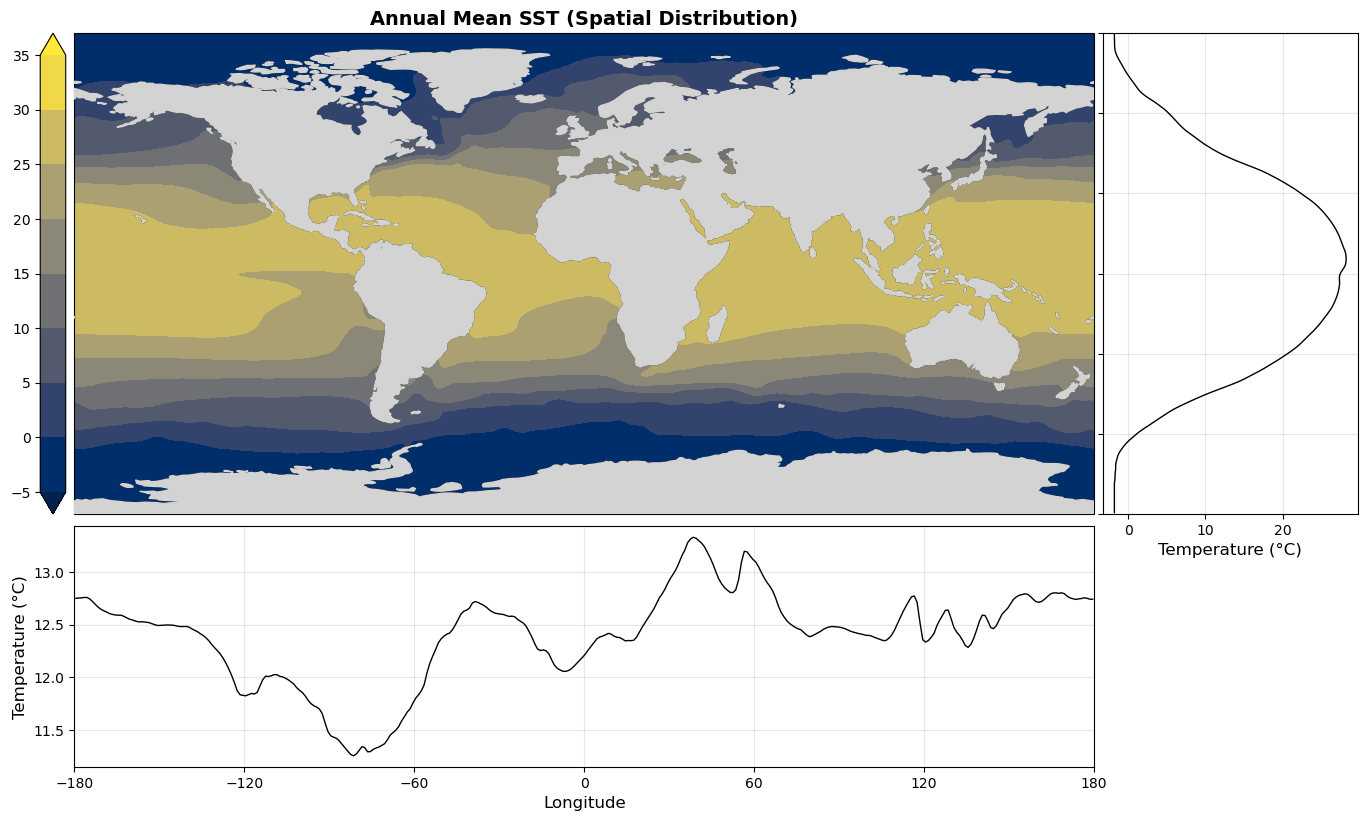

In [108]:
# Create a custom grid layout with main plot and line plots
fig = plt.figure(figsize=(17, 10))
gs = gridspec.GridSpec(3, 3, figure=fig, 
                       height_ratios=[2, 1, 0.1],  # Main plot larger, longitude profile, colorbar
                       width_ratios=[0.05, 2, 0.5],  # Colorbar, Main plot, latitude profile, spacer
                       hspace=0.05, wspace=0.02
                       )

# Calculate annual mean for all plots
annual_mean = ds_seas['sst'].mean('season')

# ax1: Large main spatial plot 
ax1 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
ax1.set_aspect('auto')  # Allow ax1 to fill the GridSpec cell completely
annual_mean_cyclic, lons = add_cyclic_point(annual_mean, coord=ds_seas['lon'])

cs_main = ax1.contourf(lons, ds_seas['lat'], annual_mean_cyclic, clevs,
                      transform=ccrs.PlateCarree(),
                      cmap='cividis', extend='both')

ax1.set_title('Annual Mean SST (Spatial Distribution)', fontsize=14, fontweight='bold')
ax1.coastlines()

# Add lat/lon labels to main plot
# ax1.set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
# ax1.set_yticks(np.arange(-90, 91, 30), crs=ccrs.PlateCarree())
# ax1.xaxis.set_major_formatter(cticker.LongitudeFormatter())
# ax1.yaxis.set_major_formatter(cticker.LatitudeFormatter())

# Colorbar on the left with same height as ax1
cbar_ax = fig.add_subplot(gs[0, 0])
cbar = fig.colorbar(cs_main, cax=cbar_ax, orientation='vertical', 
                    extend='both')
cbar.ax.yaxis.set_ticks_position('left')
cbar.ax.yaxis.set_label_position('left')

# ax2: Latitudinal mean (right panel) - mean temperature across all longitudes
# Using gs[0, 2] ensures ax2 has the same height as ax1 (both in row 0)
ax2 = fig.add_subplot(gs[0, 2])
lat_mean = annual_mean.mean('lon')  # Mean across all longitudes for each latitude

ax2.plot(lat_mean.values, lat_mean.lat, linestyle='-', linewidth=1, color='black')
ax2.set_xlabel('Temperature (°C)', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-90, 90)
ax2.set_yticks(np.arange(-90, 91, 30))
ax2.set_yticklabels('')  # Hide y-tick labels to avoid redundancy

# ax3: Longitudinal mean (bottom panel) - mean temperature across all latitudes
ax3 = fig.add_subplot(gs[1, 1])
lon_mean = annual_mean.mean('lat')  # Mean across all latitudes for each longitude
lon_mean2 = lon_mean.assign_coords(lon=(((lon_mean['lon'] +180) % 360))-180)
lon_mean2 = lon_mean2.sortby(lon_mean2['lon'])

ax3.plot(lon_mean2.lon, lon_mean2.values, linestyle='-', linewidth=1, color='black')
ax3.set_ylabel('Temperature (°C)', fontsize=12)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(-180, 180)
ax3.set_xticks(np.arange(-180, 181, 60))
ax3.set_xlabel('Longitude', fontsize=12)

# Manually align ax2 and ax3 with ax1 after layout is computed
# Get ax1's position
pos1 = ax1.get_position()

# Align ax2 vertically with ax1
pos2 = ax2.get_position()
ax2.set_position([pos2.x0, pos1.y0, pos2.width, pos1.height])

# Align ax3 horizontally with ax1
pos3 = ax3.get_position()
ax3.set_position([pos1.x0, pos3.y0, pos1.width, pos3.height])


ax1.add_feature(feature.LAND, zorder=99, color='lightgray', alpha=1)

plt.show()

In [100]:
ax1.get_aspect()

1.0

<xarray.DataArray 'lon' (lon: 360)> Size: 1kB
array([  0.5,   1.5,   2.5, ..., 357.5, 358.5, 359.5],
      shape=(360,), dtype=float32)
Coordinates:
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes:
    units:               degrees_east
    long_name:           Longitude
    actual_range:        [  0.5 359.5]
    standard_name:       longitude
    axis:                X
    coordinate_defines:  center

## 3. Complex Publication-Ready Layout

Let's create a more sophisticated layout that you might see in a scientific publication:
- Main plot with regional focus
- Smaller regional zoom-ins
- Time series plot
- Dedicated colorbar spaces

AttributeError: 'MaskedArray' object has no attribute 'sel'

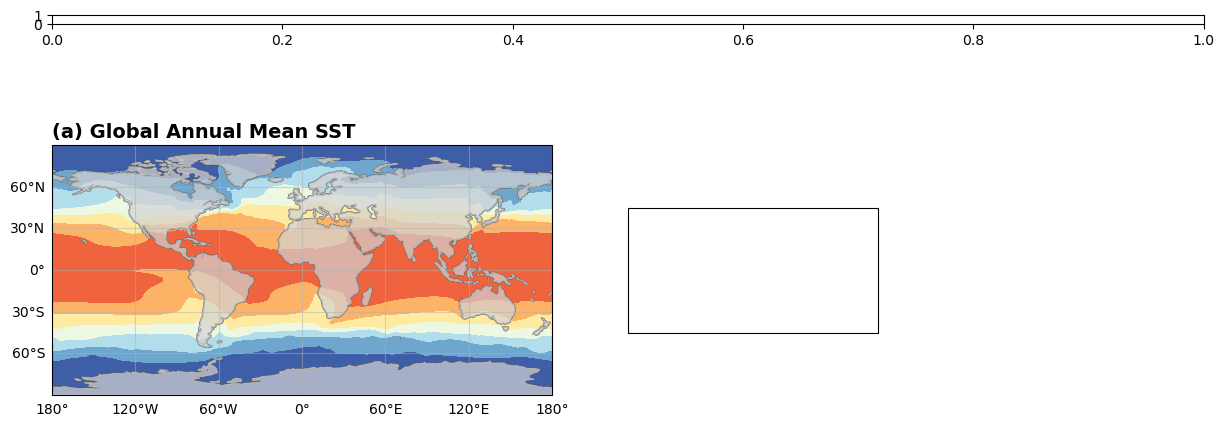

In [32]:
# Create a complex publication-ready layout
fig = plt.figure(figsize=(16, 12))

# Define a 4x4 grid with custom ratios
gs = gridspec.GridSpec(4, 4, figure=fig,
                       height_ratios=[0.05, 2, 1, 1],  # Colorbar, main, regional, timeseries
                       width_ratios=[2, 1, 1, 0.05],   # Main, regional1, regional2, colorbar
                       hspace=0.4, wspace=0.3)

# Top colorbar spanning most of the width
cbar_ax_top = fig.add_subplot(gs[0, :3])

# Main global plot (large, top-left)
ax_main = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree())
annual_mean = ds_seas['sst'].mean('season')
annual_mean, lons = add_cyclic_point(annual_mean, coord=ds_seas['lon'])

cs_main = ax_main.contourf(lons, ds_seas['lat'], annual_mean, clevs,
                          transform=ccrs.PlateCarree(),
                          cmap='RdYlBu_r', extend='both')

ax_main.set_title('(a) Global Annual Mean SST', fontsize=14, fontweight='bold', loc='left')
ax_main.coastlines()
ax_main.add_feature(feature.LAND, zorder=2, color='lightgray', alpha=0.7)
ax_main.set_global()

# Add gridlines
gl_main = ax_main.gridlines(draw_labels=True, alpha=0.5)
gl_main.top_labels = False
gl_main.right_labels = False

# Regional plot 1: North Atlantic (top-middle)
ax_regional1 = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree())
regional_data1 = annual_mean.sel(lat=slice(20, 70), lon=slice(-80, 20))

cs_r1 = ax_regional1.contourf(regional_data1.lon, regional_data1.lat, regional_data1, 
                             levels=np.arange(0, 30, 2),
                             transform=ccrs.PlateCarree(),
                             cmap='RdYlBu_r', extend='both')

ax_regional1.set_title('(b) North Atlantic', fontsize=12, fontweight='bold', loc='left')
ax_regional1.coastlines()
ax_regional1.add_feature(feature.LAND, zorder=2, color='lightgray', alpha=0.7)
ax_regional1.set_extent([-80, 20, 20, 70], crs=ccrs.PlateCarree())

# Regional plot 2: Pacific (top-right)
ax_regional2 = fig.add_subplot(gs[1, 2], projection=ccrs.PlateCarree())
regional_data2 = annual_mean.sel(lat=slice(-20, 20), lon=slice(120, 280))

cs_r2 = ax_regional2.contourf(regional_data2.lon, regional_data2.lat, regional_data2,
                             levels=np.arange(24, 32, 0.5),
                             transform=ccrs.PlateCarree(),
                             cmap='RdYlBu_r', extend='both')

ax_regional2.set_title('(c) Tropical Pacific', fontsize=12, fontweight='bold', loc='left')
ax_regional2.coastlines()
ax_regional2.add_feature(feature.LAND, zorder=2, color='lightgray', alpha=0.7)
ax_regional2.set_extent([120, 280, -20, 20], crs=ccrs.PlateCarree())

# Time series plot spanning bottom left
ax_timeseries = fig.add_subplot(gs[2:, :2])

# Create a simple seasonal cycle
seasons_order = ['DJF', 'MAM', 'JJA', 'SON']
seasonal_means = []
for season in seasons_order:
    seasonal_mean = ds_seas['sst'].sel(season=season).mean().values
    seasonal_means.append(seasonal_mean)

ax_timeseries.plot(seasons_order, seasonal_means, 'o-', linewidth=3, markersize=8, color='darkblue')
ax_timeseries.set_title('(d) Global Mean Seasonal Cycle', fontsize=12, fontweight='bold', loc='left')
ax_timeseries.set_ylabel('Global Mean SST (°C)', fontsize=11)
ax_timeseries.set_xlabel('Season', fontsize=11)
ax_timeseries.grid(True, alpha=0.3)
ax_timeseries.set_ylim([min(seasonal_means) - 0.5, max(seasonal_means) + 0.5])

# Difference plot (bottom right)
ax_diff = fig.add_subplot(gs[2, 2], projection=ccrs.PlateCarree())
jja_data = ds_seas['sst'].sel(season='JJA')
djf_data = ds_seas['sst'].sel(season='DJF')
diff_data = jja_data - djf_data
diff_data, lons = add_cyclic_point(diff_data, coord=ds_seas['lon'])

cs_diff = ax_diff.contourf(lons, ds_seas['lat'], diff_data,
                          levels=np.arange(-15, 16, 2),
                          transform=ccrs.PlateCarree(),
                          cmap='RdBu_r', extend='both')

ax_diff.set_title('(e) JJA - DJF', fontsize=12, fontweight='bold', loc='left')
ax_diff.coastlines()
ax_diff.add_feature(feature.LAND, zorder=2, color='lightgray', alpha=0.7)

# Histogram (bottom far right)
ax_hist = fig.add_subplot(gs[3, 2])
global_sst = annual_mean.values.flatten()
global_sst = global_sst[~np.isnan(global_sst)]

ax_hist.hist(global_sst, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
ax_hist.set_title('(f) SST Distribution', fontsize=12, fontweight='bold', loc='left')
ax_hist.set_xlabel('Temperature (°C)', fontsize=10)
ax_hist.set_ylabel('Frequency', fontsize=10)
ax_hist.grid(True, alpha=0.3)

# Add colorbars
cbar_main = fig.colorbar(cs_main, cax=cbar_ax_top, orientation='horizontal',
                        label='Sea Surface Temperature (°C)', extend='both')

# Side colorbar for difference plot
cbar_ax_side = fig.add_subplot(gs[2, 3])
cbar_diff = fig.colorbar(cs_diff, cax=cbar_ax_side, orientation='vertical',
                        label='Temp Diff (°C)', extend='both')

plt.suptitle('Complex Multi-Panel Scientific Figure with GridSpec', fontsize=18, y=0.97)
plt.show()

## 4. Nested GridSpecs and Advanced Colorbar Placement

GridSpec can be nested to create even more complex layouts. This is useful when you want different spacing rules for different sections of your figure.